### **추가분석 3: 규제 직전/직후 단기 변화 분석**

#### 2021년 5월 도로교통법 개정과 2021년 7월 서울시 견인조치 전후 6개월/12개월을 비교해, 장기 추세가 아니라 단기 단절 효과가 있었는지 확인합니다.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
import warnings
warnings.filterwarnings('ignore')

BASE_PATH = Path(r'N:/개인/대학교/2026/고급프로그래밍/Term-Project(고급프로그래밍설계 01분반 10조)')


In [5]:
pm_month = pd.read_csv(BASE_PATH / '데이터 전처리/서울시 PM 교통사고 현황/서울시_자치구별_월별_PM교통사고.csv', encoding='utf-8')
pm_month['연월_dt'] = pd.to_datetime(pm_month['연월'] + '-01')

monthly = pm_month.groupby('연월_dt', as_index=False).agg(
    PM_사고건수=('PM_사고건수', 'sum'),
    중상이상자수=('중상이상자수', 'sum'),
    사망자수=('사망자수', 'sum'),
    야간사고건수=('야간사고건수', 'sum')
).sort_values('연월_dt')

def window_summary(label, before_start, before_end, after_start, after_end):
    before = monthly[(monthly['연월_dt'] >= before_start) & (monthly['연월_dt'] <= before_end)]
    after = monthly[(monthly['연월_dt'] >= after_start) & (monthly['연월_dt'] <= after_end)]
    b_acc, a_acc = before['PM_사고건수'].mean(), after['PM_사고건수'].mean()
    b_total, a_total = before['PM_사고건수'].sum(), after['PM_사고건수'].sum()
    return {
        '비교구간': label,
        '이전기간': f"{before_start:%Y-%m}~{before_end:%Y-%m}",
        '이후기간': f"{after_start:%Y-%m}~{after_end:%Y-%m}",
        '이전_월평균_PM사고': b_acc,
        '이후_월평균_PM사고': a_acc,
        '월평균_증감률(%)': (a_acc - b_acc) / b_acc * 100,
        '이전_중상이상비율(%)': before['중상이상자수'].sum() / b_total * 100,
        '이후_중상이상비율(%)': after['중상이상자수'].sum() / a_total * 100,
        '중상이상비율_증감(pp)': after['중상이상자수'].sum() / a_total * 100 - before['중상이상자수'].sum() / b_total * 100,
    }

short = pd.DataFrame([
    window_summary('도로교통법 개정 전후 6개월', pd.Timestamp('2020-11-01'), pd.Timestamp('2021-04-01'), pd.Timestamp('2021-06-01'), pd.Timestamp('2021-11-01')),
    window_summary('서울시 견인조치 전후 6개월', pd.Timestamp('2021-01-01'), pd.Timestamp('2021-06-01'), pd.Timestamp('2021-08-01'), pd.Timestamp('2022-01-01')),
    window_summary('서울시 견인조치 전후 12개월', pd.Timestamp('2020-07-01'), pd.Timestamp('2021-06-01'), pd.Timestamp('2021-08-01'), pd.Timestamp('2022-07-01')),
])
display(short)


,비교구간,이전기간,이후기간,이전_월평균_PM사고,이후_월평균_PM사고,월평균_증감률(%),이전_중상이상비율(%),이후_중상이상비율(%),중상이상비율_증감(pp)
0,도로교통법 개정 전후 6개월,2020-11~2021-04,2021-06~2021-11,43.666667,58.666667,34.351145,25.572519,29.829545,4.257026
1,서울시 견인조치 전후 6개월,2021-01~2021-06,2021-08~2022-01,51.166667,47.166667,-7.817590,24.755700,27.208481,2.452780
2,서울시 견인조치 전후 12개월,2020-07~2021-06,2021-08~2022-07,56.666667,47.416667,-16.323529,26.323529,27.943761,1.620232


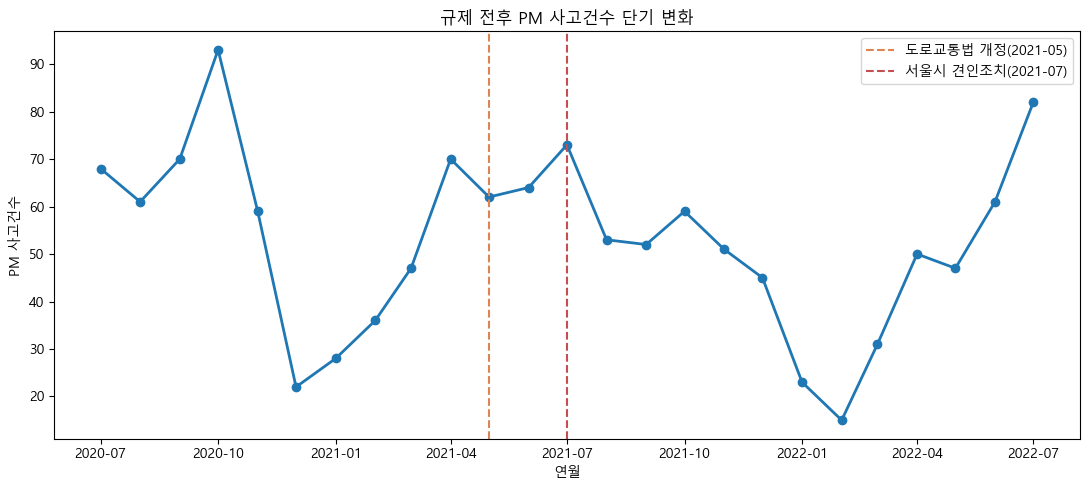

In [6]:
plot_df = monthly[(monthly['연월_dt'] >= '2020-07-01') & (monthly['연월_dt'] <= '2022-07-01')].copy()
plt.figure(figsize=(11, 5))
plt.plot(plot_df['연월_dt'], plot_df['PM_사고건수'], marker='o', linewidth=2)
plt.axvline(pd.Timestamp('2021-05-01'), color='#dd8452', linestyle='--', label='도로교통법 개정(2021-05)')
plt.axvline(pd.Timestamp('2021-07-01'), color='#c44e52', linestyle='--', label='서울시 견인조치(2021-07)')
plt.title('규제 전후 PM 사고건수 단기 변화')
plt.xlabel('연월')
plt.ylabel('PM 사고건수')
plt.legend()
plt.tight_layout()
plt.show()


#### 결과 요약

| 비교구간 | 이전_월평균_PM사고 | 이후_월평균_PM사고 | 월평균_증감률(%) | 이전_중상이상비율(%) | 이후_중상이상비율(%) | 중상이상비율_증감(pp) |
| --- | --- | --- | --- | --- | --- | --- |
| 도로교통법 개정 전후 6개월 | 43.67 | 58.67 | 34.35 | 25.57 | 29.83 | 4.26 |
| 서울시 견인조치 전후 6개월 | 51.17 | 47.17 | -7.82 | 24.76 | 27.21 | 2.45 |
| 서울시 견인조치 전후 12개월 | 56.67 | 47.42 | -16.32 | 26.32 | 27.94 | 1.62 |

- 직전/직후 단기 비교에서도 PM 사고 건수 감소 효과는 뚜렷하지 않습니다.
- 세부적으로는 도로교통법 개정 전후 6개월에는 월평균 사고가 증가했고, 서울시 견인조치 전후 6개월/12개월에는 단기 감소가 관찰됩니다.
- 다만 견인조치 구간에서도 중상이상 비율은 낮아지지 않았고, 전체 기간 분석에서는 사고 건수 증가가 확인되므로 `지속적 사고 감소 효과`로 단정하기는 어렵습니다.